# Load the Dataset

In [30]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Student_Performance.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Rename subject columns to engineering subjects
df.rename(columns={
    'math_score': 'computer_network_score',
    'science_score': 'operating_system_score',
    'english_score': 'daa_score'
}, inplace=True)

# Drop student_id as it's not useful for prediction
df.drop('student_id', axis=1, inplace=True)

print("Renamed columns and dropped student_id")
print("New columns:", df.columns.tolist())

Dataset shape: (25000, 16)
Columns: ['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']
Renamed columns and dropped student_id
New columns: ['age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score', 'final_grade']


# Handle Missing Values

In [31]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())


Missing values:
 age                       0
gender                    0
school_type               0
parent_education          0
study_hours               0
attendance_percentage     0
internet_access           0
travel_time               0
extra_activities          0
study_method              0
computer_network_score    0
operating_system_score    0
daa_score                 0
overall_score             0
final_grade               0
dtype: int64


# Remove Duplicates

In [32]:
# Check for duplicates
print("Duplicates before:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicates before: 10000
Duplicates after: 0
Dataset shape after removing duplicates: (15000, 15)


# Detect and Handle Outliers

In [33]:
import numpy as np

# Numerical columns
numerical_cols = ['age', 'study_hours', 'attendance_percentage', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score']

# Detect outliers using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"{col}: {outliers.sum()} outliers")

# For scores, cap at 0-100
score_cols = ['computer_network_score', 'operating_system_score', 'daa_score', 'overall_score']
for col in score_cols:
    df[col] = np.clip(df[col], 0, 100)

print("Outliers handled by capping scores at 0-100")

age: 0 outliers
study_hours: 0 outliers
attendance_percentage: 0 outliers
computer_network_score: 5 outliers
operating_system_score: 4 outliers
daa_score: 2 outliers
overall_score: 0 outliers
Outliers handled by capping scores at 0-100


# Encode Categorical Variables

In [34]:
# Identify categorical features (excluding target)
categorical_features = [col for col in df.select_dtypes(include=['object']).columns if col != 'final_grade']
print("Categorical features:", categorical_features)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
print("Encoded columns:", df_encoded.columns.tolist())

Categorical features: ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']
Encoded dataset shape: (15000, 26)
Encoded columns: ['age', 'study_hours', 'attendance_percentage', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score', 'final_grade', 'gender_male', 'gender_other', 'school_type_public', 'parent_education_graduate', 'parent_education_high school', 'parent_education_no formal', 'parent_education_phd', 'parent_education_post graduate', 'internet_access_yes', 'travel_time_30-60 min', 'travel_time_<15 min', 'travel_time_>60 min', 'extra_activities_yes', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook']


C:\Users\prama\AppData\Local\Temp\ipykernel_40632\1575607772.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = [col for col in df.select_dtypes(include=['object']).columns if col != 'final_grade']


# Exploratory Data Analysis (EDA)

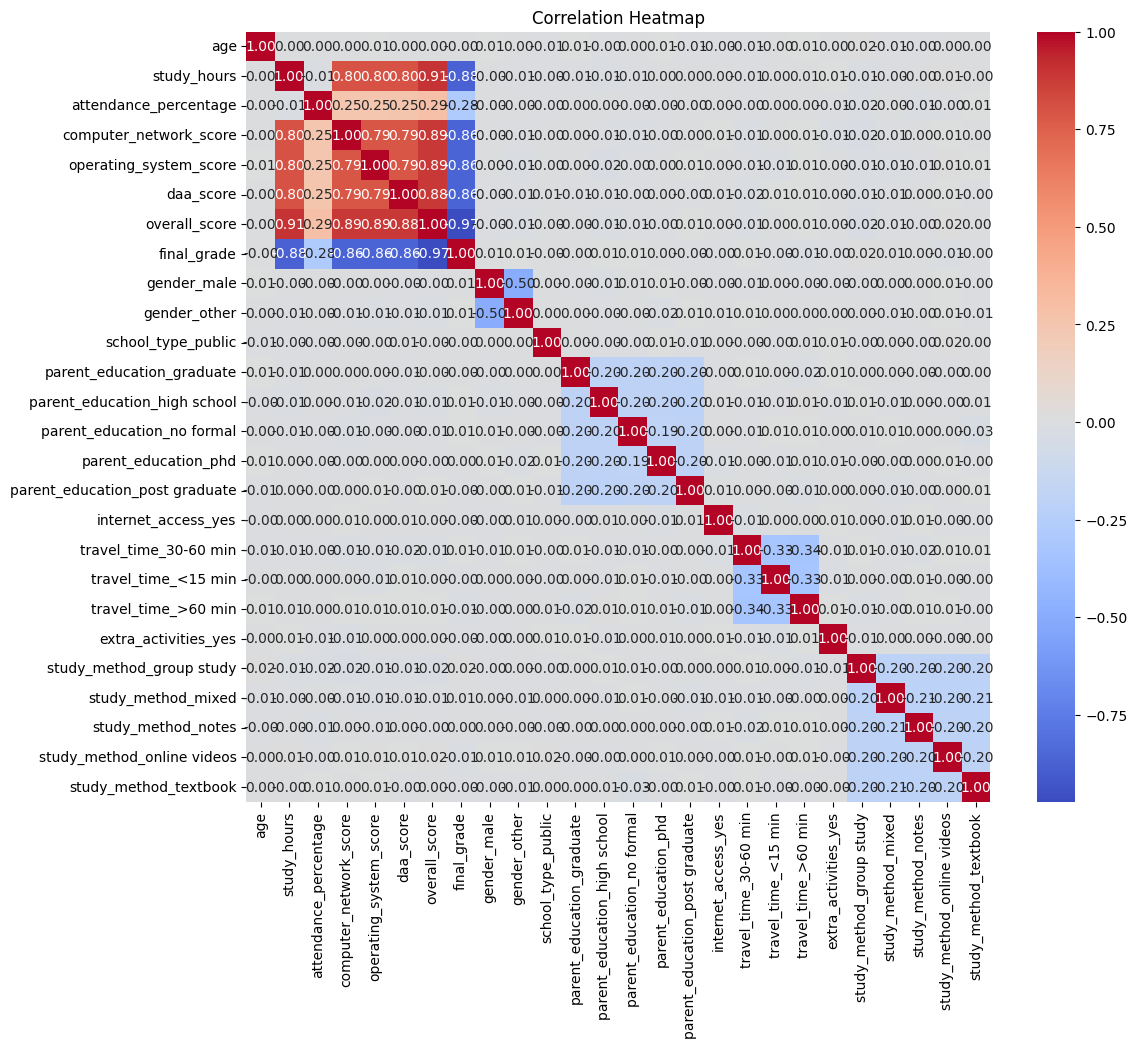

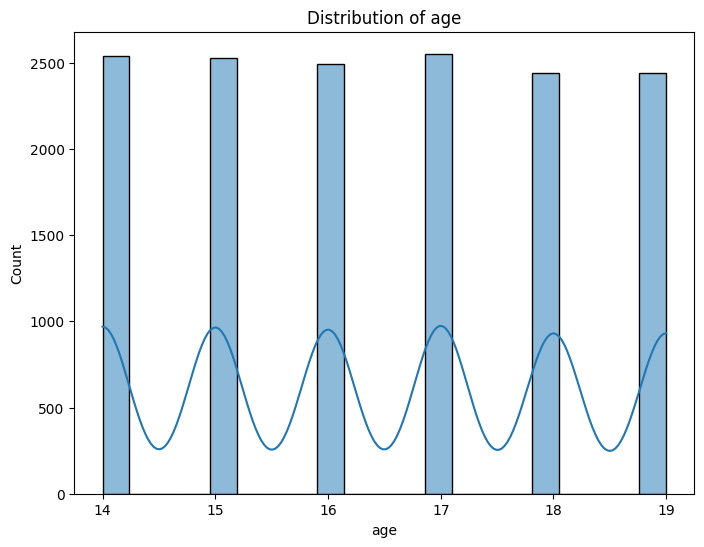

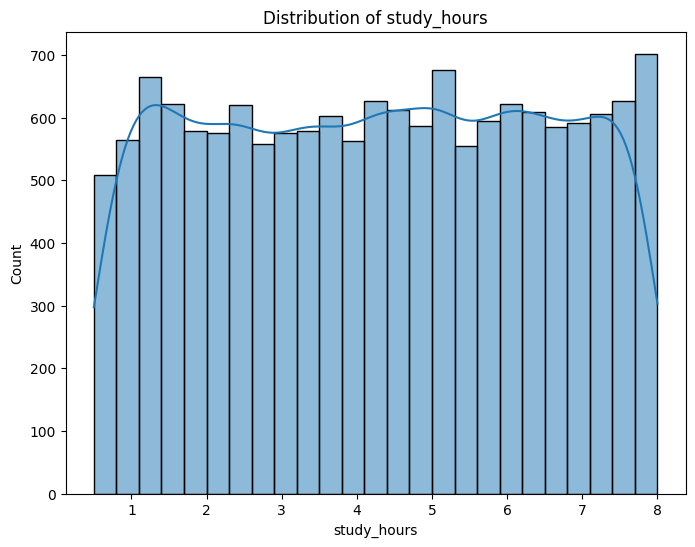

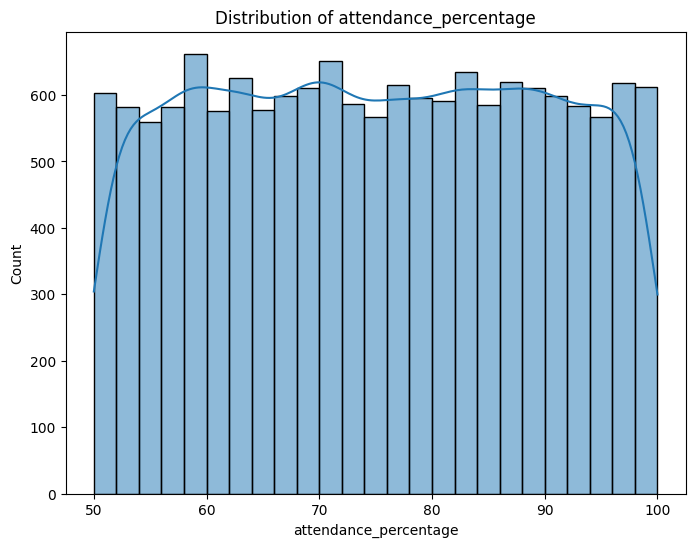

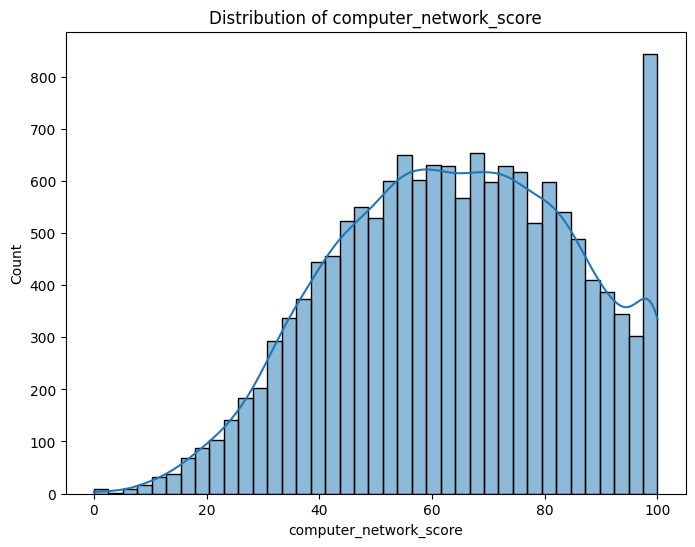

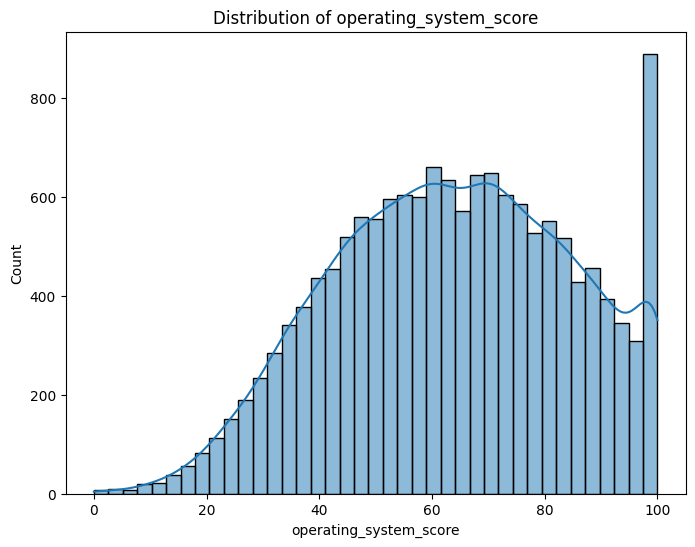

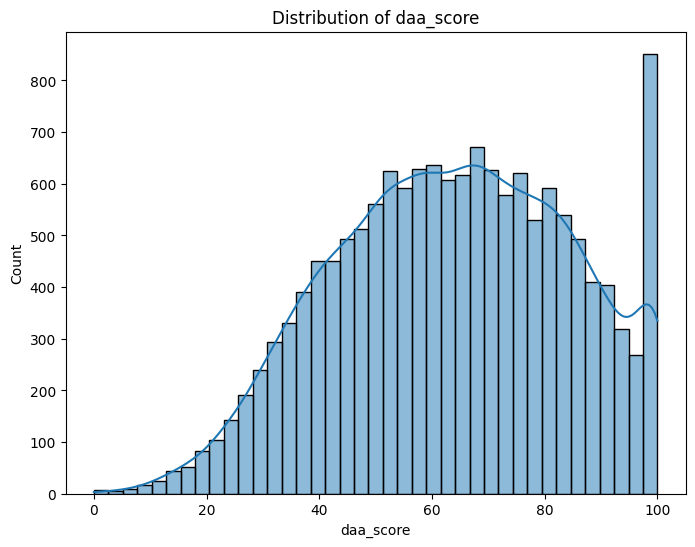

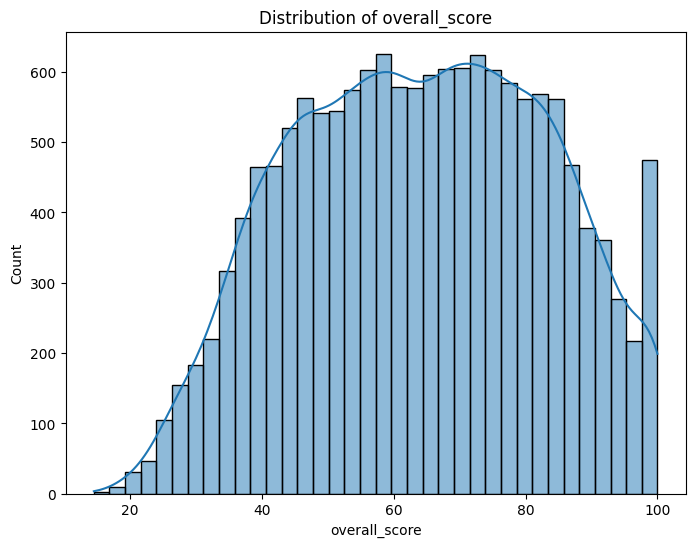

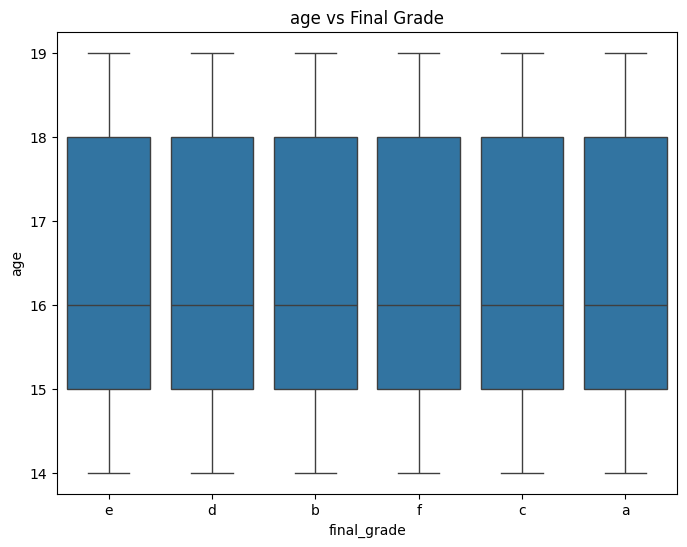

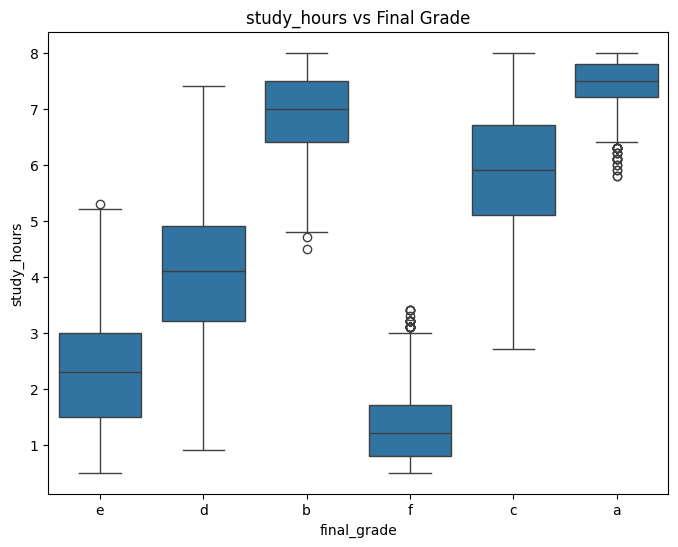

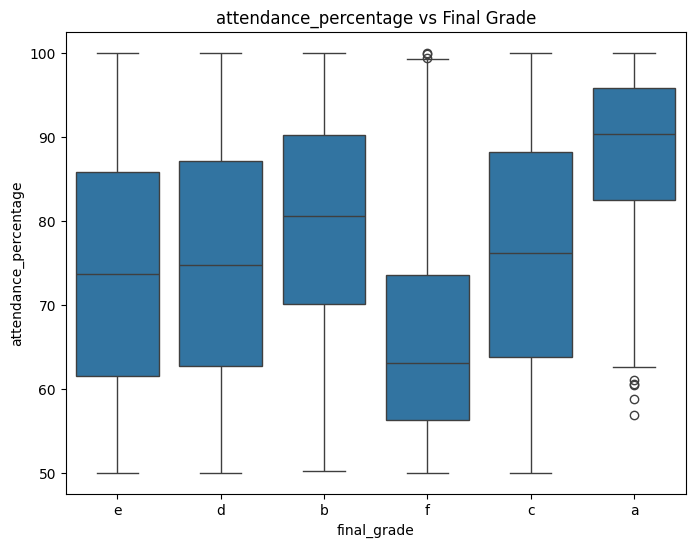

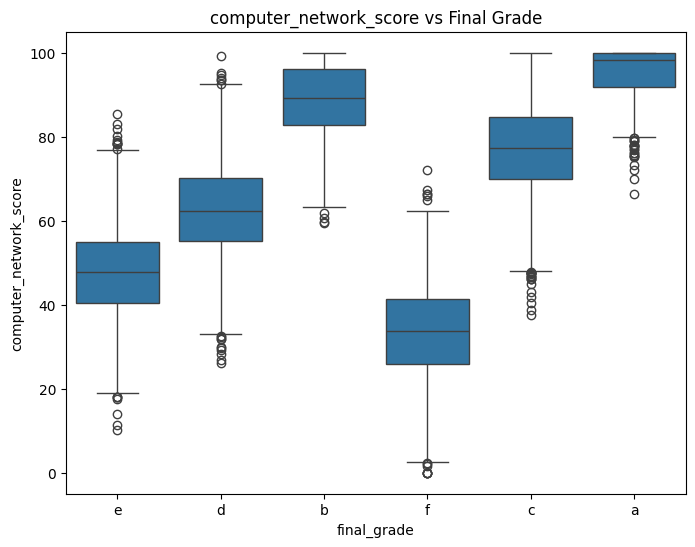

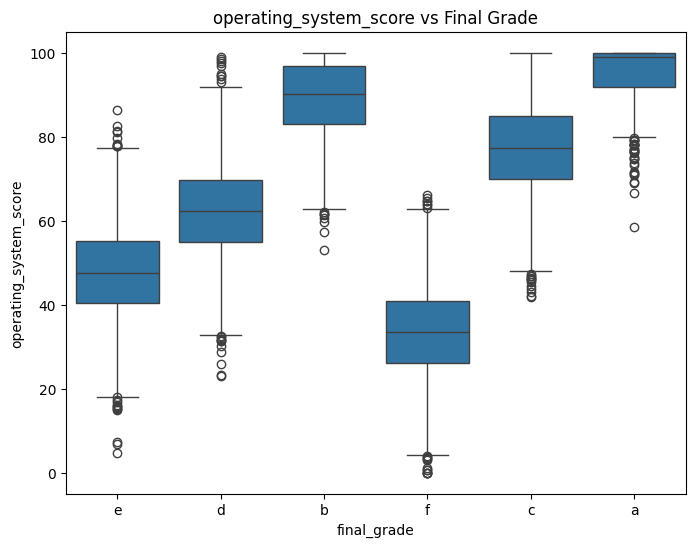

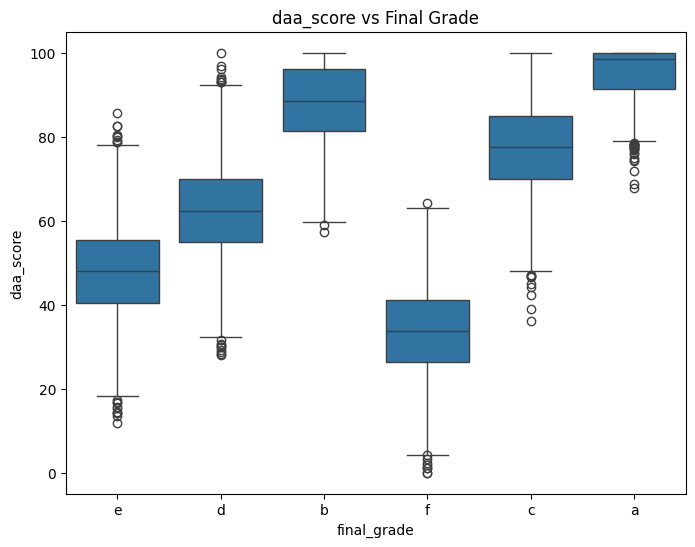

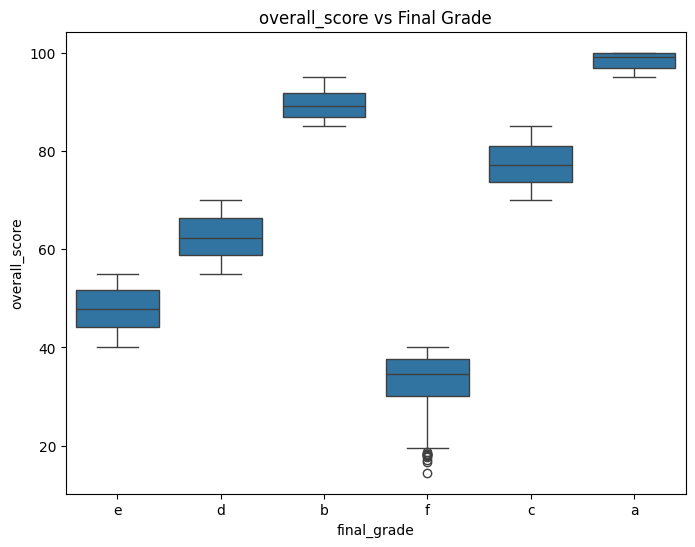

C:\Users\prama\AppData\Local\Temp\ipykernel_40632\2638961242.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


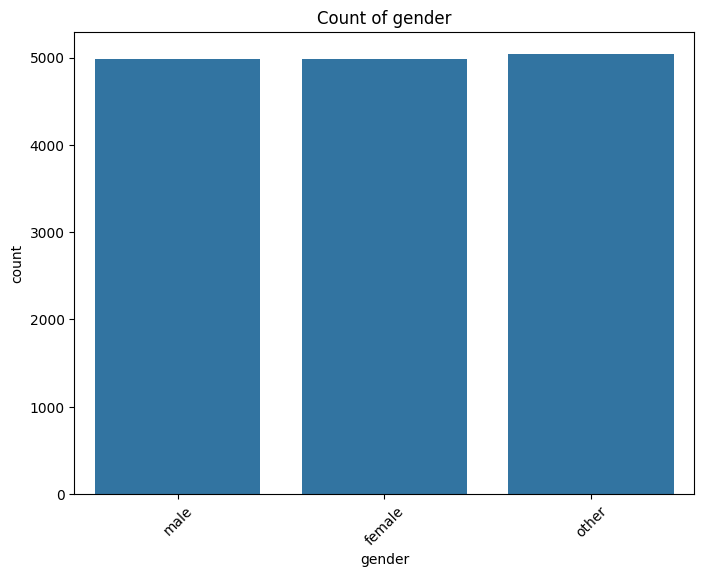

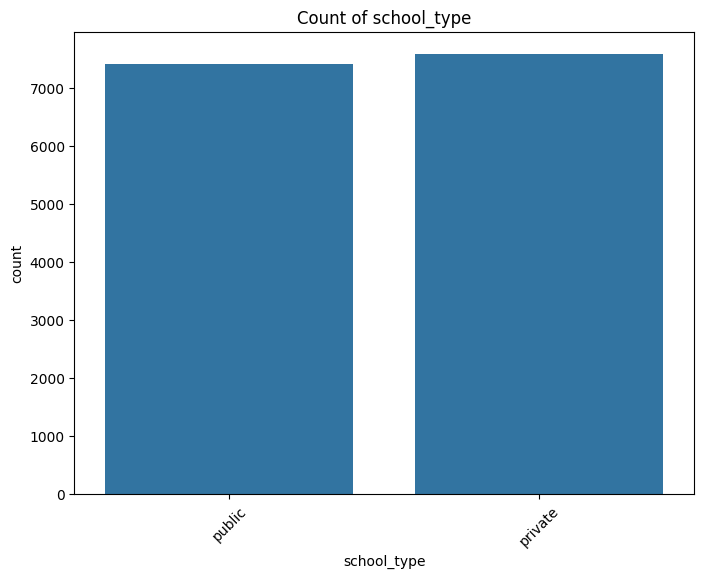

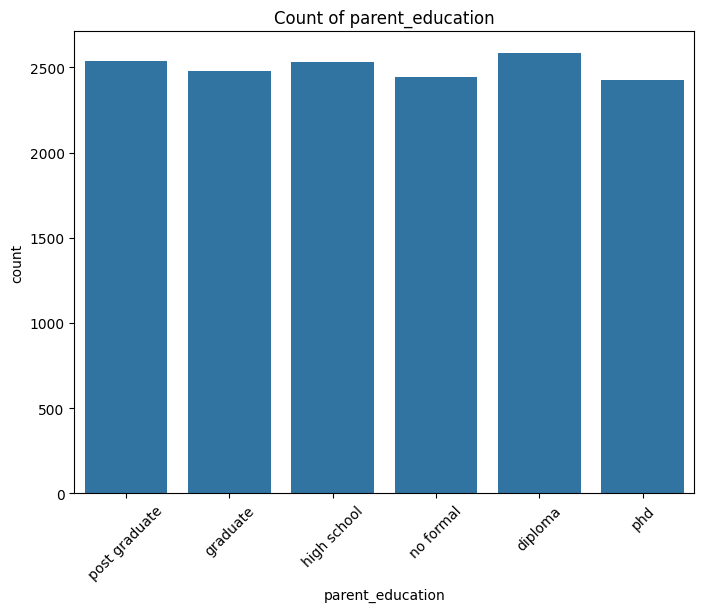

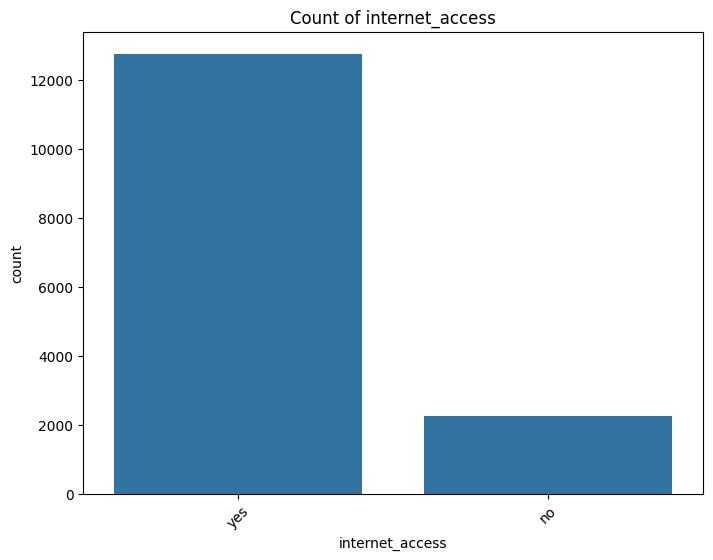

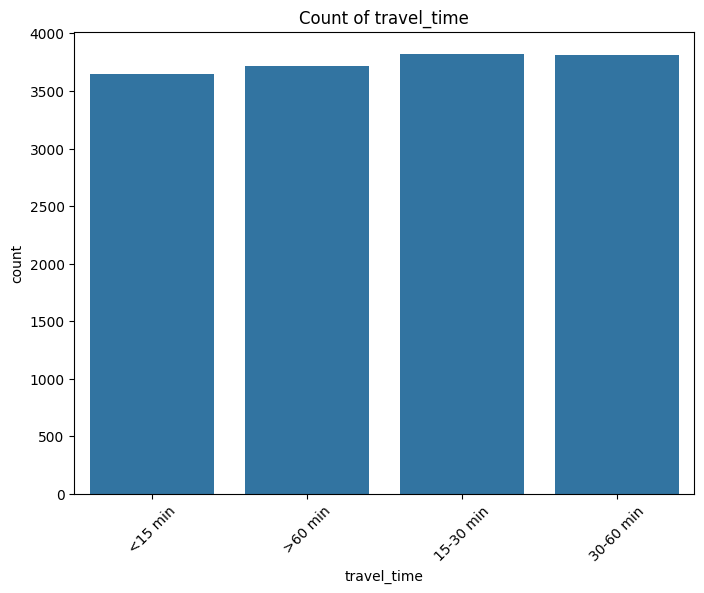

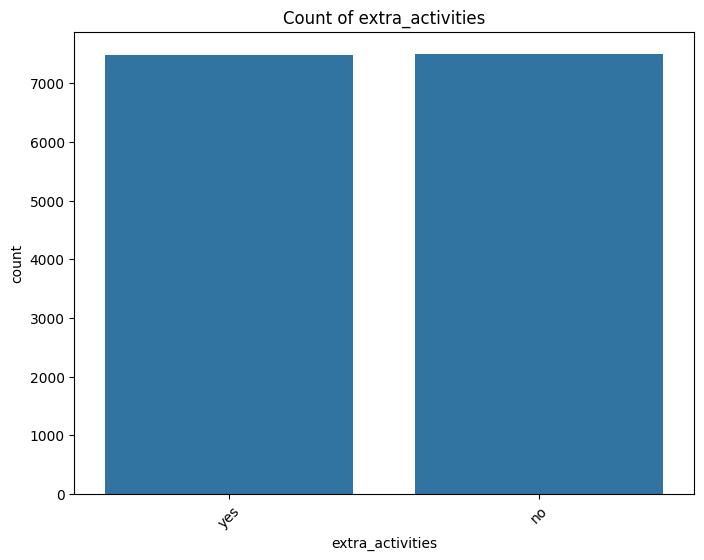

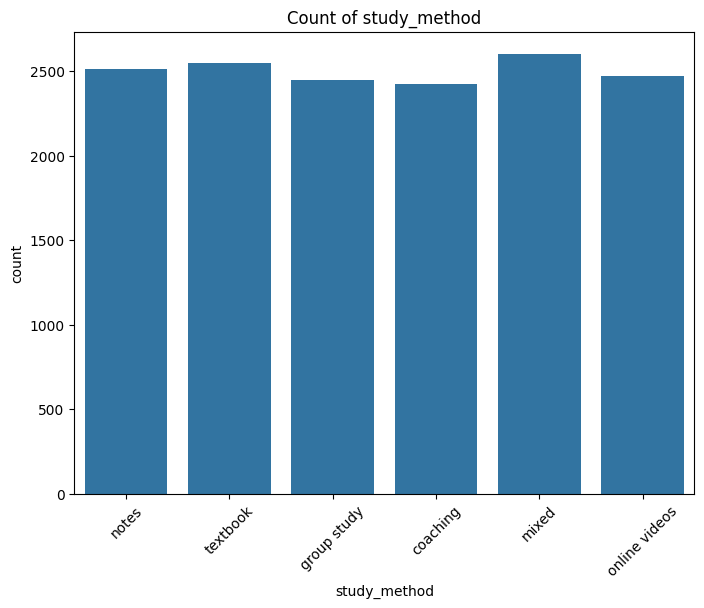

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os

# Create plots directory
os.makedirs('plots', exist_ok=True)

# Encode target for correlation
le_corr = LabelEncoder()
y_encoded = le_corr.fit_transform(df['final_grade'])

# Correlation heatmap
df_encoded_copy = df_encoded.copy()
df_encoded_copy['final_grade'] = y_encoded
plt.figure(figsize=(12, 10))
corr = df_encoded_copy.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('plots/correlation_heatmap.png')
plt.show()

# Plot distributions for numerical features
numerical_cols = ['age', 'study_hours', 'attendance_percentage', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score']
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'plots/{col}_distribution.png')
    plt.show()

# Boxplots for numerical features vs target
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='final_grade', y=col, data=df)
    plt.title(f'{col} vs Final Grade')
    plt.savefig(f'plots/{col}_vs_grade.png')
    plt.show()

# Count plots for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if col != 'final_grade':
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df)
        plt.title(f'Count of {col}')
        plt.xticks(rotation=45)
        plt.savefig(f'plots/{col}_count.png')
        plt.show()

## Feature Selection and Scale Numerical Features

In [36]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pickle

# Numerical columns
numerical_cols = ['age', 'study_hours', 'attendance_percentage', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score']

# Separate features and target
X = df_encoded.drop('final_grade', axis=1)
y = df_encoded['final_grade']

# Encode target for feature selection
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y_encoded)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features.tolist())

# Use selected features
X = X[selected_features]

# Scale selected numerical features
numerical_selected = [col for col in selected_features if col in numerical_cols]
scaler = StandardScaler()
X[numerical_selected] = scaler.fit_transform(X[numerical_selected])

print("Selected numerical features scaled")

# Save selected features and numerical selected for API
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features.tolist(), f)

with open('numerical_selected.pkl', 'wb') as f:
    pickle.dump(numerical_selected, f)

Selected features: ['study_hours', 'attendance_percentage', 'computer_network_score', 'operating_system_score', 'daa_score', 'overall_score', 'parent_education_high school', 'internet_access_yes', 'travel_time_>60 min', 'study_method_group study']
Selected numerical features scaled


# Split the Data

In [37]:
from sklearn.model_selection import train_test_split

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (12000, 10) (12000,)
Test shape: (3000, 10) (3000,)


# Train Machine Learning Models using the specific algorithms

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }
    print(f"{name} - Accuracy: {results[name]['accuracy']:.4f}")

# Select best model based on accuracy
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

Logistic Regression - Accuracy: 0.9487
Random Forest - Accuracy: 0.9960
Gradient Boosting - Accuracy: 0.9967
SVM - Accuracy: 0.9603
KNN - Accuracy: 0.8410
Best model: Gradient Boosting


# Evaluate the Model

In [39]:
# Print detailed results
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        print(f"  {metric.capitalize()}: {value:.4f}")

# Save the best model
import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\nBest model saved as 'best_model.pkl'")


Logistic Regression:
  Accuracy: 0.9487
  Precision: 0.9488
  Recall: 0.9487
  F1: 0.9487

Random Forest:
  Accuracy: 0.9960
  Precision: 0.9960
  Recall: 0.9960
  F1: 0.9960

Gradient Boosting:
  Accuracy: 0.9967
  Precision: 0.9967
  Recall: 0.9967
  F1: 0.9967

SVM:
  Accuracy: 0.9603
  Precision: 0.9604
  Recall: 0.9603
  F1: 0.9603

KNN:
  Accuracy: 0.8410
  Precision: 0.8412
  Recall: 0.8410
  F1: 0.8408

Best model saved as 'best_model.pkl'


In [40]:
# Save scaler and label encoder for API
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Scaler and label encoder saved")

Scaler and label encoder saved


# Model Accuracy Comparison - Bar Chart

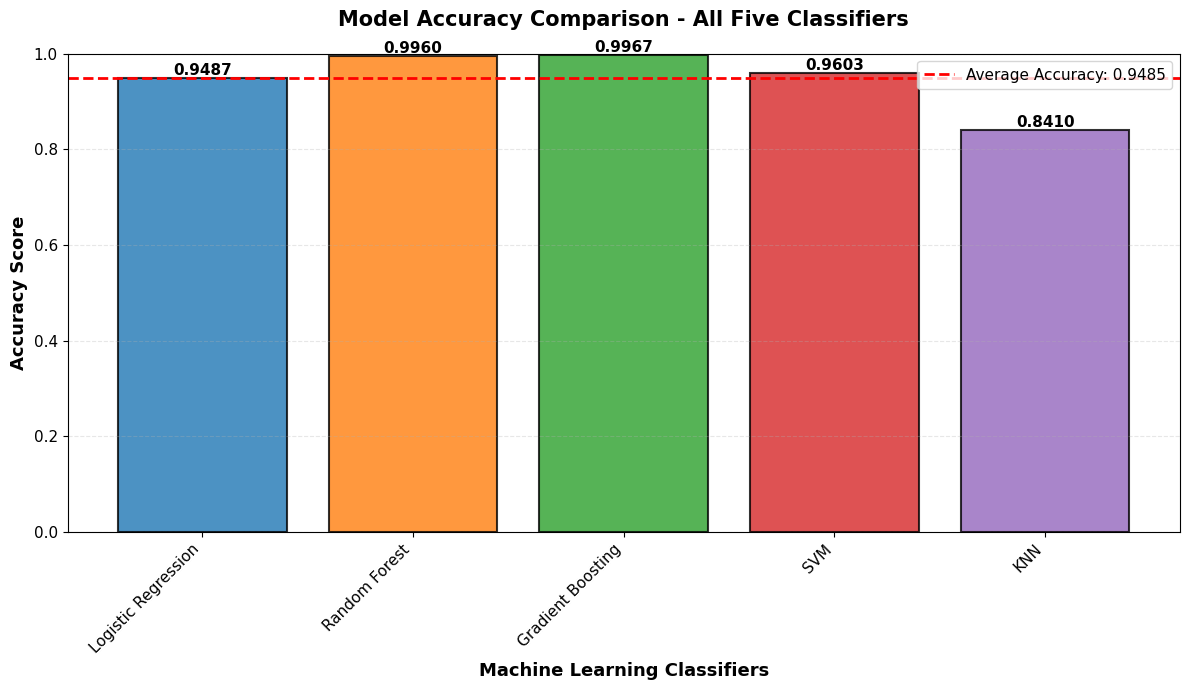

MODEL ACCURACY COMPARISON - ALL FIVE CLASSIFIERS
Logistic Regression..................... 0.9487
Random Forest........................... 0.9960
Gradient Boosting....................... 0.9967
SVM..................................... 0.9603
KNN..................................... 0.8410
Average Accuracy........................ 0.9485
Best Model.............................. Gradient Boosting (0.9967)


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract accuracy scores from all models
model_names = list(results.keys())
accuracy_scores = [results[name]['accuracy'] for name in model_names]

# Create figure with better styling
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = plt.bar(model_names, accuracy_scores, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for bar, score in zip(bars, accuracy_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the plot
plt.ylabel('Accuracy Score', fontsize=13, fontweight='bold')
plt.xlabel('Machine Learning Classifiers', fontsize=13, fontweight='bold')
plt.title('Model Accuracy Comparison - All Five Classifiers', fontsize=15, fontweight='bold', pad=20)
plt.ylim([0, 1])
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add a horizontal line for average accuracy
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)
plt.axhline(y=average_accuracy, color='red', linestyle='--', linewidth=2, label=f'Average Accuracy: {average_accuracy:.4f}')
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plots/model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 70)
print("MODEL ACCURACY COMPARISON - ALL FIVE CLASSIFIERS")
print("=" * 70)
for name, accuracy in zip(model_names, accuracy_scores):
    print(f"{name:.<40} {accuracy:.4f}")
print("=" * 70)
print(f"{'Average Accuracy':.<40} {average_accuracy:.4f}")
print(f"{'Best Model':.<40} {best_model_name} ({results[best_model_name]['accuracy']:.4f})")
print("=" * 70)

# Gradient Boosting Classifier - Confusion Matrix & Metrics

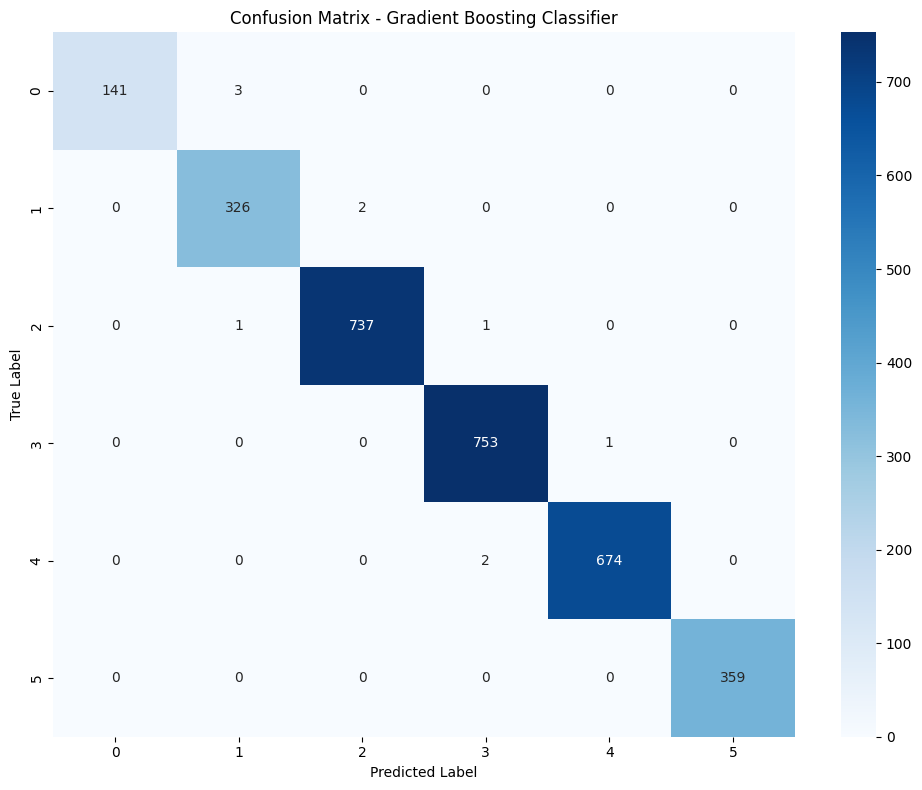

GRADIENT BOOSTING CLASSIFIER - DETAILED METRICS

Confusion Matrix:
[[141   3   0   0   0   0]
 [  0 326   2   0   0   0]
 [  0   1 737   1   0   0]
 [  0   0   0 753   1   0]
 [  0   0   0   2 674   0]
 [  0   0   0   0   0 359]]

Classification Report:
              precision    recall  f1-score   support

           a       1.00      0.98      0.99       144
           b       0.99      0.99      0.99       328
           c       1.00      1.00      1.00       739
           d       1.00      1.00      1.00       754
           e       1.00      1.00      1.00       676
           f       1.00      1.00      1.00       359

    accuracy                           1.00      3000
   macro avg       1.00      0.99      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from Gradient Boosting Classifier
gb_model = models['Gradient Boosting']
y_pred_gb = gb_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("=" * 60)
print("GRADIENT BOOSTING CLASSIFIER - DETAILED METRICS")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm)
print("\n" + "=" * 60)
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_gb))

# Top 10 Features - Feature Importance Rankings


TOP 10 FEATURES - IMPORTANCE RANKING (Gradient Boosting)
                     Feature   Importance
               overall_score 9.993043e-01
      operating_system_score 2.254644e-04
                 study_hours 1.270885e-04
                   daa_score 8.041364e-05
         internet_access_yes 7.301834e-05
       attendance_percentage 6.570688e-05
         travel_time_>60 min 5.596568e-05
      computer_network_score 5.166594e-05
    study_method_group study 1.599711e-05
parent_education_high school 3.641999e-07


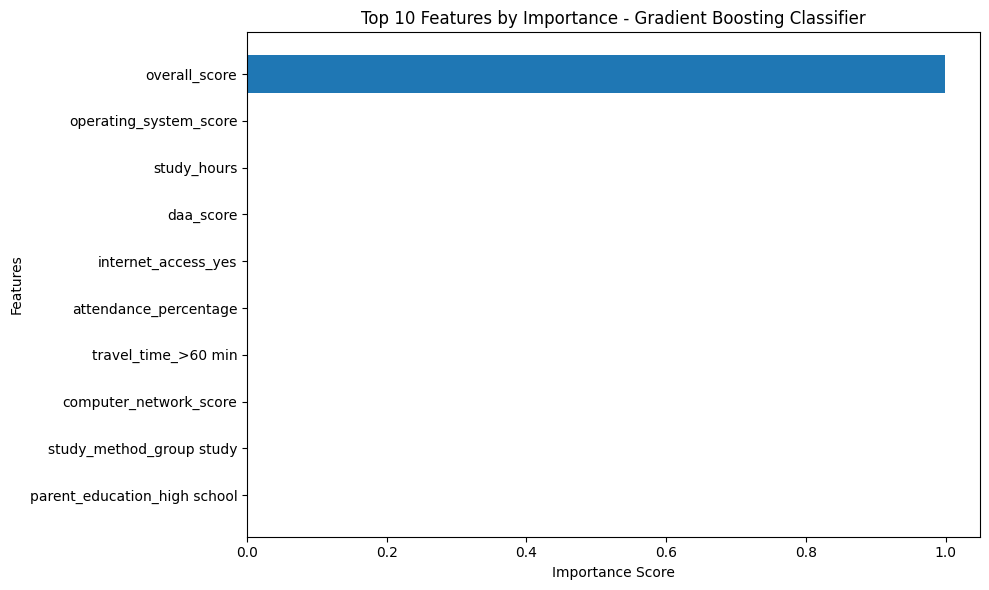


Feature Importance Summary:
overall_score........................... 0.999304
operating_system_score.................. 0.000225
study_hours............................. 0.000127
daa_score............................... 0.000080
internet_access_yes..................... 0.000073
attendance_percentage................... 0.000066
travel_time_>60 min..................... 0.000056
computer_network_score.................. 0.000052
study_method_group study................ 0.000016
parent_education_high school............ 0.000000


In [43]:
# Extract feature importances from Gradient Boosting Classifier
feature_importance = gb_model.feature_importances_
feature_names = X_train.columns

# Create a dataframe for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Get top 10 features
top_10_features = importance_df.head(10)

print("\n" + "=" * 60)
print("TOP 10 FEATURES - IMPORTANCE RANKING (Gradient Boosting)")
print("=" * 60)
print(top_10_features.to_string(index=False))
print("=" * 60)

# Visualize top 10 features
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_10_features)), top_10_features['Importance'].values)
plt.yticks(range(len(top_10_features)), top_10_features['Feature'].values)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Features by Importance - Gradient Boosting Classifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Summary:")
for idx, row in top_10_features.iterrows():
    print(f"{row['Feature']:.<40} {row['Importance']:.6f}")

# ROC Curves for All Five Classifiers

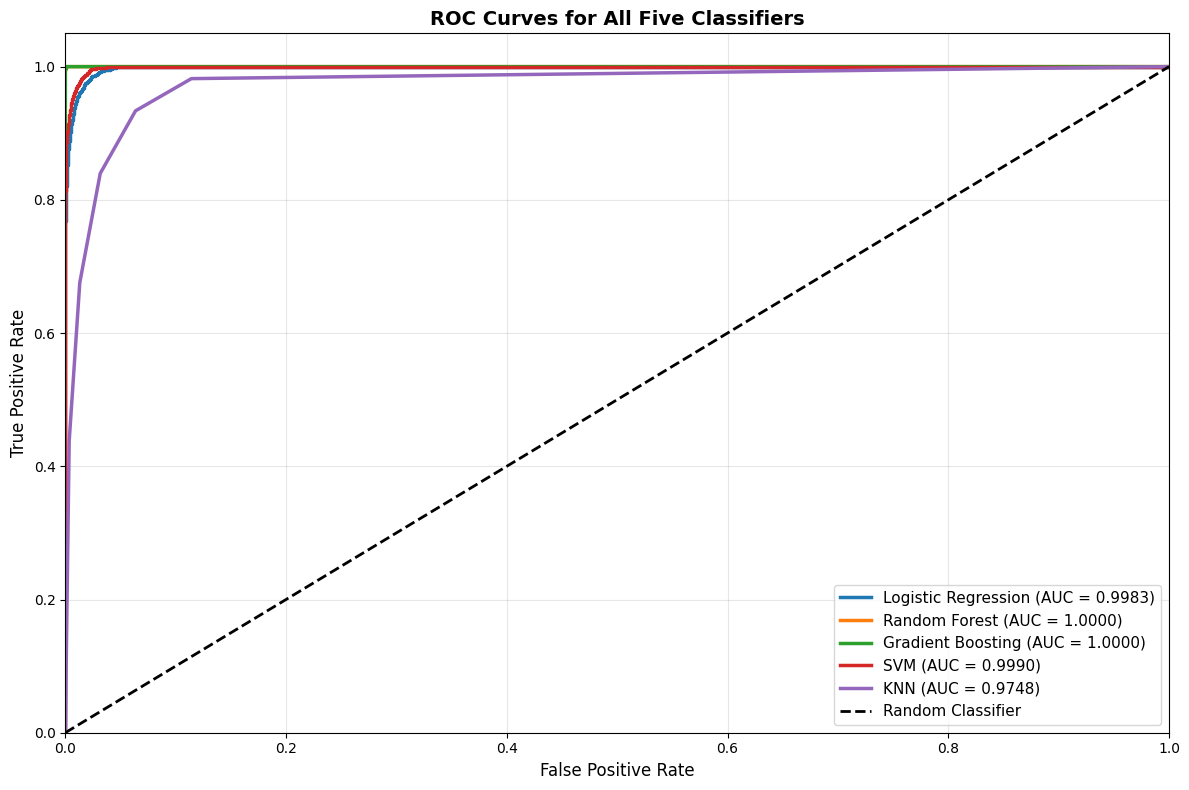

ROC Curves plotted and saved!


In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Prepare data for ROC curves
y_test_bin = label_binarize(y_test, classes=le.classes_)
n_classes = y_test_bin.shape[1]

# Create figure
plt.figure(figsize=(12, 8))

# Plot ROC curve for each classifier
for name, model in models.items():
    # Get prediction probabilities
    y_proba = model.predict_proba(X_test)
    
    # Compute ROC curve and AUC
    if n_classes == 2:
        # Binary classification
        fpr, tpr, _ = roc_curve(y_test_bin[:, 1], y_proba[:, 1])
    else:
        # Multiclass - use one-vs-rest approach
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

# Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for All Five Classifiers', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/roc_curves_all_classifiers.png', dpi=300)
plt.show()

print("ROC Curves plotted and saved!")
